# 26. Simple Linear Regression — Hands-On with scikit-learn

This is the hands-on notebook that [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD) promised — same `cgpa → package` story, same `y = m·x + c` idea, but now actually built with real code on the `placement.csv` dataset, using `scikit-learn`.

Every code cell below has a short comment on every line explaining what that line does, plus a markdown note before it explaining *why* that step exists. Nothing here is a random dot on a chart — you'll always know whose CGPA and package a point represents, because we track the full 100-row dataset the whole way through.

In [1]:
import pandas as pd                                     # pandas: load the CSV and work with it as a table (DataFrame)
import seaborn as sns                                    # seaborn: nicer statistical plots, built on top of matplotlib
import matplotlib.pyplot as plt                          # matplotlib: base plotting library, used here for fine control (labels, legends, saving files)
from sklearn.model_selection import train_test_split     # splits our data into a training pool and a held-back testing pool
from sklearn.linear_model import LinearRegression        # the actual Simple Linear Regression model class

## Step 1 — Load the dataset

`placement.csv` is the same CGPA → package sheet from [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD), just as a real CSV file this time instead of a screenshot. `pd.read_csv` reads it straight into a pandas DataFrame — a table with rows and columns that stay lined up together.

In [2]:
dataset = pd.read_csv("placement.csv")  # read the CSV file from disk into a pandas DataFrame called "dataset"

## Step 2 — Peek at the first few rows

Before doing anything else, always look at a few real rows. This confirms the column names (`cgpa`, `package`) and that the values look like what we expect — no surprises like text sitting in a number column.

In [3]:
dataset.head(3)  # show only the first 3 rows, just to eyeball the columns and their values

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25


## Step 3 — Check for missing values

This is the same data-cleaning habit from earlier `ML/` topics: before training anything, confirm there are no gaps. `scikit-learn` cannot train on missing (`NaN`) values.

In [4]:
dataset.isnull().sum()  # count missing values in every column — should be 0 for both, since this dataset is already clean

cgpa       0
package    0
dtype: int64

## Step 4 — Pull out `x` (the input) from the dataset

`x` is the independent variable — the thing we already know and predict *from* (see the [`y = m·x + c` naming](25_Simple_Linear_Regression.MD#the-equation-y--mx--c)). Right now we grab it the most obvious way: a single column, pulled out with single square brackets.

In [5]:
x = dataset["cgpa"]   # pull out just the "cgpa" column, using single brackets — this returns a 1-D pandas Series, not a table
x                      # display it, to see what we just built

0     6.89
1     5.12
2     7.82
3     7.42
4     6.94
      ... 
95    5.22
96    7.16
97    6.06
98    6.61
99    7.15
Name: cgpa, Length: 100, dtype: float64

## Step 5 — Check its shape with `.ndim`

`.ndim` tells us how many dimensions an object has. A plain column (Series) is 1-D — think of it as one flat list of numbers, with no separate "column concept" baked in.

In [6]:
x.ndim  # 1 = one dimension (a flat Series), not the 2-D table shape scikit-learn expects for its inputs

1

## Step 6 — Fix the shape: `x` needs to be 2-D

`scikit-learn`'s models always expect `x` (the features) as a 2-D table — rows × columns — **even when there's only one column**, because the model is built to accept many feature columns in general (this is exactly the door to Multiple Linear Regression, coming up next per [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD#coming-up-next)). `y` (the target) is the one exception — it's allowed to stay 1-D, since there's always exactly one target.

The fix: use **double** square brackets, `dataset[["cgpa"]]`, instead of single ones. Passing a *list* of column names — even a list with just one name in it — tells pandas "keep this as a table," not "flatten it into a Series."

In [7]:
x = dataset[["cgpa"]]  # double brackets: pass a list of one column name, so pandas keeps this as a DataFrame (2-D table), not a flattened Series

In [8]:
x.ndim  # now 2 = two dimensions (a table with 1 column) — this is the shape scikit-learn expects

2

## Step 7 — Pull out `y` (the target)

`y` is the dependent variable — the package we're trying to predict. Unlike `x`, `y` is allowed to stay 1-D (a plain Series), so single brackets are correct here.

In [9]:
y = dataset["package"]   # pull out the "package" column as a 1-D Series — this is fine for y, unlike x
y                          # display it

0     3.26
1     1.98
2     3.25
3     3.67
4     3.57
      ... 
95    1.60
96    2.61
97    2.49
98    3.23
99    3.06
Name: package, Length: 100, dtype: float64

## Step 8 — Check the linearity assumption, visually

Simple Linear Regression only makes sense if `cgpa` and `package` roughly move together in a straight-line pattern. Before fitting anything, plot every row as a dot — this is exactly the scatter plot described in [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD#visualizing-the-relationship).

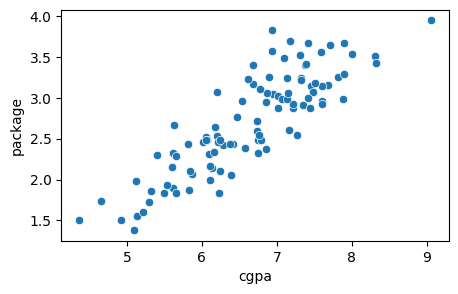

In [10]:
plt.figure(figsize=(5,3))                              # open a new, fairly small figure to draw on
sns.scatterplot(x="cgpa", y="package", data=dataset)    # one dot per student: cgpa on the x-axis, package on the y-axis
plt.show()                                              # render the plot

The dots trend upward, left to right — higher `cgpa` tends to go with a higher `package`. That's the visual sign of a **positive slope**, and it's enough evidence to justify trying Simple Linear Regression on this data (see the [slope table](25_Simple_Linear_Regression.MD#understanding-the-slope-m) in `25_Simple_Linear_Regression.MD`).

## Step 9 — Split into training and test data

We can't fairly test the model on the same rows it learned from — that would be like grading a student on the exact questions they memorized the answers to. `train_test_split` randomly divides the 100 rows into two separate pools:

- `test_size=0.2` → hold back 20% of the rows (20 students) purely for testing, never shown during training.
- `random_state=42` → fixes the "random" shuffle to always be the same one, so results are reproducible every time this notebook runs.

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 80 rows go to *_train, 20 rows go to *_test

## Step 10 — Build the model, and train it

`LinearRegression()` creates an empty, untrained model object — at this point it doesn't know `m` or `c` yet. `.fit(x_train, y_train)` is the actual training step: this is where `scikit-learn` searches for the best `m` and `c` using Ordinary Least Squares (see [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD#how-the-model-actually-finds-the-best-m-and-c)), using only the 80 training rows.

In [12]:
lr = LinearRegression()          # create a fresh, untrained Simple Linear Regression model
lr.fit(x_train, y_train)         # train it on the 80 training rows — this is where sklearn works out the best m (slope) and c (intercept)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.172
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## Step 11 — Try one real prediction

Row 0 of the CSV is a real student: `cgpa = 6.89`, actual `package = 3.26`. Feed the model that same `cgpa` and see what it predicts, so we can compare a real answer against the model's guess.

One detail: `x` was trained as a DataFrame with a column named `"cgpa"` (Step 6). Handing `.predict()` a bare list like `[[6.89]]` still works, but `scikit-learn` warns that it's missing that column name. Wrapping the new value in a one-row DataFrame with the same column name avoids the warning and is the more correct way to feed new data in.

In [13]:
# row 0 in the CSV: cgpa=6.89, package=3.26 (actual) — let's see what the model predicts for that same cgpa
new_row = pd.DataFrame([[6.89]], columns=["cgpa"])   # wrap the new cgpa value in a DataFrame with the matching column name
lr.predict(new_row)                                   # ask the trained model to predict the package for cgpa=6.89

array([2.83654417])

The model predicts **2.83**, but the real value in the CSV is **3.26** — a gap of about 0.43. One point being off isn't a verdict on the whole model though; we need a score across *all* the test rows, not just this one, to judge it fairly.

## Step 12 — Score the model on unseen data

`lr.score(x_test, y_test)` returns the model's **R² score** — roughly, "what fraction of the up-and-down movement in `package` does `cgpa` explain?" `1.0` (100%) would mean a perfect line through every test point; `0.0` would mean the line explains nothing at all. Multiplying by 100 just turns it into a percentage-style number that's easier to read.

In [14]:
lr.score(x_test, y_test) * 100  # R² score on the 20 held-back test rows, as a percentage-style number

68.79138403839303

**~68.8%.** That means `cgpa` explains a good chunk of the variation in `package`, but there's still a meaningful amount left unexplained — other things (internships, projects, interview performance, luck) likely matter too. For a *simple* regression with just one input feature, this is a believable, middling score — not broken, but not great either.

## Step 13 — Inspect what the model actually learned: `m` and `c`

We're not retraining here — we're looking *inside* the already-trained model to read off the two numbers it settled on: the slope (`lr.coef_`) and the intercept (`lr.intercept_`). Together they fully define the line the model fitted (see [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD#the-equation-y--mx--c)).

In [15]:
lr.coef_  # the slope, m — an array because sklearn supports many features at once; here there's only one value, for "cgpa". Positive → the line rises left to right.

array([0.58176641])

In [16]:
lr.intercept_  # the intercept, c — a single number here. Negative → the line crosses the y-axis below zero (it dips below the x-axis before turning positive).

np.float64(-1.1718264038996313)

## Step 14 — Write out the fitted equation

Plugging the two numbers above into `y = m·x + c` gives the exact formula this model uses for every prediction.

In [17]:
# y = 0.58176641 * x + (-1.1718264038996313)  <- this run's fitted line, shown for reference only; the next cell reads these numbers from the model itself instead of retyping them

## Step 15 — Recreate that prediction by hand

To prove the equation above is exactly what `.predict()` uses internally, calculate it manually — but pull `m` and `c` **directly from the trained model** (`lr.coef_[0]` and `lr.intercept_`) rather than retyping the printed numbers. Typing the numbers by hand would silently go stale if the model were ever retrained (different data, different `random_state`); reading them from the model itself can't drift out of sync.

In [18]:
m = lr.coef_[0]                     # pull the slope straight out of the trained model, instead of retyping the printed number
c = lr.intercept_                   # pull the intercept straight out of the trained model
manual_prediction = m * 6.89 + c    # apply y = m*x + c by hand, for the same cgpa=6.89 used in Step 11
manual_prediction

np.float64(2.8365441666439155)

**2.8365...** — the same value as `lr.predict()` gave in Step 11 (down to rounding). That confirms the model really is just the one straight line `y = m·x + c`; `.predict()` isn't doing anything more exotic than plugging numbers into that formula.

## Step 16 — Predict across the *whole* dataset, to draw the fitted line

So far we predicted for a single `cgpa`. To actually draw the fitted line on a chart, we need a predicted `package` for **every** row in `x` (all 100 students, not just the 20 test ones) — that gives us enough points to trace the full line from one end of the data to the other.

In [19]:
y_prd = lr.predict(x)  # predict the package for every row in x (all 100 students) — used to draw the fitted line

## Step 17 — Plot the fitted line over the actual data (and fix a legend bug)

The original version of this cell had:

```python
plt.legend("org", "predict_line")
```

That's the line commented "check this line why its not working." `plt.legend()` does **not** take two plain label strings as positional arguments like that. When two positional arguments are passed, matplotlib treats the *first* as a list of plot **handles** (the actual line/point objects) and the second as a list of **labels** — not "here are two label strings." Since `"org"` is a string, matplotlib iterates over its individual *characters* (`'o'`, `'r'`, `'g'`) looking for plottable objects, finds none, and quietly draws an **empty legend box** — with a `UserWarning: Legend does not support handles for str instances` in the background — instead of raising a hard error. That's exactly why it looked like "nothing happens": no crash, just a legend with no entries in it.

**The fix:** give each plotted series its own `label="..."` when it's drawn, then call `plt.legend()` with no arguments at all — matplotlib automatically collects every labeled artist on the axes.

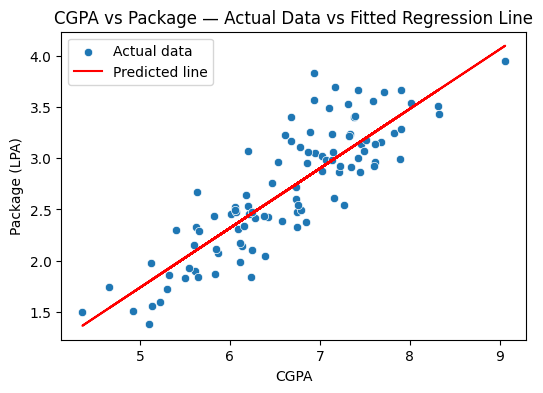

In [20]:
plt.figure(figsize=(6,4))                                                  # open a new figure, a bit wider for the legend/labels
sns.scatterplot(x="cgpa", y="package", data=dataset, label="Actual data")  # label the real data points, so the legend can find them
plt.plot(dataset["cgpa"], y_prd, c="red", label="Predicted line")          # label the fitted line the same way
plt.xlabel("CGPA")                                                         # name the x-axis
plt.ylabel("Package (LPA)")                                                # name the y-axis
plt.title("CGPA vs Package — Actual Data vs Fitted Regression Line")       # title the chart
plt.legend()                                                               # this now works: it reads the labels above automatically, no args needed
plt.savefig("predict.jpg")                                                 # save a copy of the chart to disk, as before
plt.show()                                                                 # render it

## Extra visualization 1 — Residuals as vertical gaps

[`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD#residuals--the-gaps-between-the-line-and-real-points) described residuals as the gap between a real point and the line's prediction at that same `x`. Here they are, drawn directly: a thin dashed vertical line from every actual point down (or up) to the fitted line. Long dashed lines are the students the model's line predicts worst; short ones are where it's nearly spot on.

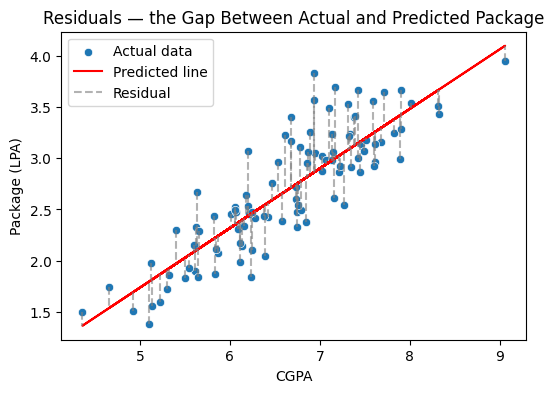

In [21]:
plt.figure(figsize=(6,4))                                                   # new figure for this visualization
sns.scatterplot(x="cgpa", y="package", data=dataset, label="Actual data")   # the real data points again
plt.plot(dataset["cgpa"], y_prd, c="red", label="Predicted line")           # the fitted line again
plt.vlines(dataset["cgpa"], y, y_prd, colors="gray", linestyles="dashed", alpha=0.6, label="Residual")  # one dashed line per student, from actual y down/up to predicted y
plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("Residuals — the Gap Between Actual and Predicted Package")
plt.legend()
plt.show()

## Extra visualization 2 — Residuals vs predicted values

A classic diagnostic chart: x-axis is what the model *predicted*, y-axis is the residual (`actual - predicted`) for that same student. A horizontal line at `0` marks "perfect prediction." If the dots scatter randomly above and below that line with no obvious pattern, the straight-line assumption is holding up reasonably well. If instead they curve or fan out, that's a sign a straight line isn't the right shape for this data.

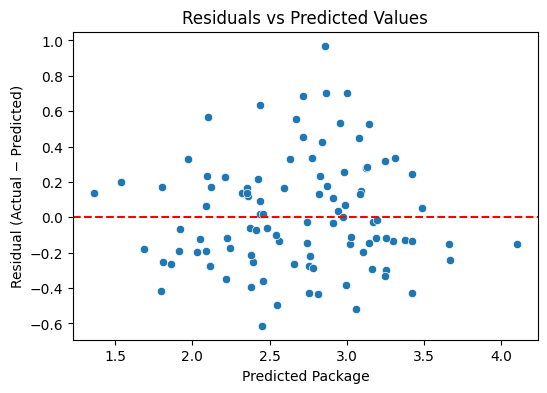

In [22]:
residuals = y - y_prd                                            # actual minus predicted, for every student — positive means the model under-predicted, negative means it over-predicted

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_prd, y=residuals)                             # predicted package on x, residual on y
plt.axhline(0, color="red", linestyle="--")                       # a flat reference line at residual=0, i.e. "perfect prediction"
plt.xlabel("Predicted Package")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residuals vs Predicted Values")
plt.show()

## Extra visualization 3 — Distribution of the residuals

A histogram of the same residuals from above, but just the shape of their spread rather than tied to any one `cgpa`. A well-behaved linear model tends to have residuals roughly centered on `0` and roughly symmetric — no long one-sided tail. This is a quick visual gut-check on how "balanced" the model's mistakes are.

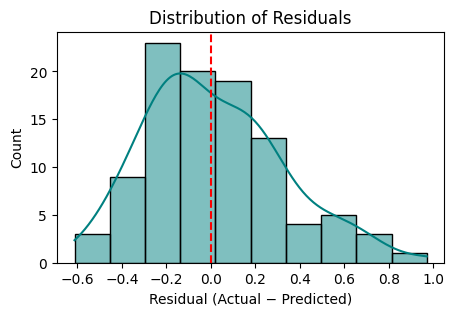

In [23]:
plt.figure(figsize=(5,3))
sns.histplot(residuals, kde=True, color="teal")   # bar-chart of how often each residual size occurs, plus a smoothed curve (kde) over it
plt.axvline(0, color="red", linestyle="--")        # mark residual=0 for reference
plt.xlabel("Residual (Actual − Predicted)")
plt.title("Distribution of Residuals")
plt.show()

## Extra visualization 4 — Actual vs predicted, on one scale

One more way to see model quality: plot actual `package` against predicted `package` directly, with a dashed diagonal reference line where `actual == predicted`. A dot sitting exactly on that diagonal is a perfect prediction for that student; the further a dot strays from the diagonal, the bigger that student's error. This view makes the ~68.8% R² score from Step 12 visible as *spread around the diagonal*, rather than as an abstract percentage.

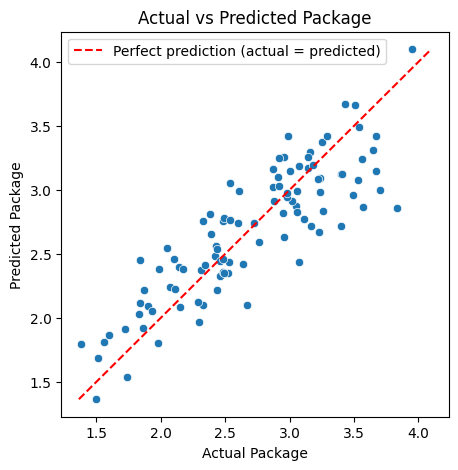

In [24]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=y, y=y_prd)                                       # actual package on x, predicted package on y
lims = [min(y.min(), y_prd.min()), max(y.max(), y_prd.max())]        # shared axis limits, so the diagonal line spans the full plot
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction (actual = predicted)")  # the y = x reference line
plt.xlabel("Actual Package")
plt.ylabel("Predicted Package")
plt.title("Actual vs Predicted Package")
plt.legend()
plt.show()

## Key Takeaways

- `x` (features) must be 2-D for `scikit-learn`, even with one column — use double brackets (`dataset[["cgpa"]]`); `y` (target) stays 1-D.
- `.fit()` searches for the best `m` and `c`; `lr.coef_` and `lr.intercept_` let you read them back out directly from the trained model instead of hardcoding printed numbers.
- A single prediction being off (2.83 vs 3.26) doesn't tell you much — `lr.score()` (R²) on held-back test data is the fair, whole-dataset judgment call; here it's ~68.8%, decent but not great for a one-feature model.
- `plt.legend()` reads its labels from each plotted series' own `label="..."` — passing strings straight into `plt.legend(...)` positionally does not do what it looks like it should.
- Residual plots (the vertical-gap chart, residuals-vs-predicted, and the residual histogram) all visualize the *same* underlying errors from different angles — together they say more about model quality than the R² number alone.

**Coming up next:** Multiple Linear Regression — the same `y = m·x + c` idea, extended to more than one input feature (see [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD#coming-up-next)).